In [1]:
!pip --q install qiskit qiskit-machine-learning matplotlib pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 6.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 90.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 86.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 5.6 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.metrics import accuracy_score, confusion_matrix


from qiskit import QuantumCircuit
from qiskit.circuit.library import z_feature_map, zz_feature_map
from qiskit.circuit.library import RealAmplitudes
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit.primitives import StatevectorEstimator as Estimator
from qiskit_machine_learning.algorithms import NeuralNetworkClassifier
from qiskit_machine_learning.optimizers import COBYLA
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit import ParameterVector

In [3]:
#Creamos un dataset

def generate_image(size = 4, vertical=True):
    img = np.random.rand(size, size) * 0.2

    if vertical:
        col = np.random.randint(0, size)
        img[:, col] = 1
    else:
        row = np.random.randint(0,size)
        img[row,:] = 1
    return img

def generate_dataset(n_samples = 100, size = 4):
    X = []
    y = []

    for _ in range(n_samples):
        if np.random.rand() > 0.5:
            img = generate_image(size, vertical=True)
            label = 1
        else:
            img = generate_image(size, vertical=False)
            label = -1

        X.append(img.flatten())
        y.append(label)

    return np.array(X), np.array(y)

def show_image(img, label):
    plt.imshow(img, cmap='gray')
    plt.axis('Off')
    plt.title(f'Ejemplo Imagen generada con label: {label}')
    plt.show()


#Funcion de callback para almacenar funcion de perdida

def callback(weigth, loss):
  loss_history.append(loss)

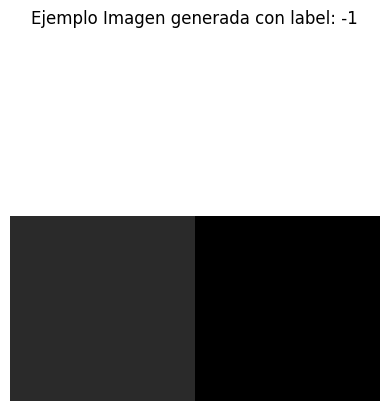

Train labels: (array([-1,  1]), array([75, 75]))
Test labels: (array([-1,  1]), array([25, 25]))


In [16]:
size = 2
num_qubits = size**2
X, y = generate_dataset(200, size=size)

# split
split = 150
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

#Mostramos una imagen
show_image(X_train[1].reshape(size,size), y_train[1])

print("Train labels:", np.unique(y_train, return_counts=True))
print("Test labels:", np.unique(y_test, return_counts=True))

In [17]:
#Seria como los kernels
def conv_circuit(params):
  qc = QuantumCircuit(2)

  qc.rz(-np.pi/2,1)
  qc.cx(1,0)
  qc.rz(params[0],0)
  qc.ry(params[1],1)
  qc.cx(0,1)
  qc.ry(params[2], 1)
  qc.cx(1, 0)
  qc.rz(np.pi/2, 0)
  qc.barrier()
  return qc

def conv_layer(qubit_indices, param_prefix):
    num_qubits = max(qubit_indices) + 1
    qc = QuantumCircuit(num_qubits)

    params = ParameterVector(param_prefix, length=len(qubit_indices) * 3)
    param_index = 0

    # pares (0,1), (2,3)...
    for i in range(0, len(qubit_indices), 2):
        if i + 1 < len(qubit_indices):
            q0 = qubit_indices[i]
            q1 = qubit_indices[i+1]

            qc.compose(
                conv_circuit(params[param_index:param_index+3]),
                [q0, q1],
                inplace=True
            )
            param_index += 3

    # pares desplazados
    for i in range(1, len(qubit_indices)-1, 2):
        q0 = qubit_indices[i]
        q1 = qubit_indices[i+1]

        qc.compose(
            conv_circuit(params[param_index:param_index+3]),
            [q0, q1],
            inplace=True
        )
        param_index += 3

    return qc


#Pooling cuantico
def pool_circuit(params):
  qc = QuantumCircuit(2)
  qc.cx(0, 1)
  qc.ry(params[0], 0)
  qc.rz(params[1], 1)

  return qc

#Capa de pooling
def pool_layer(sources, sinks, param_prefix):
    num_qubits = max(sources + sinks) + 1
    qc = QuantumCircuit(num_qubits)

    params = ParameterVector(param_prefix, length=len(sources) * 2)

    for i, (s, t) in enumerate(zip(sources, sinks)):
        qc.compose(
            pool_circuit(params[2*i:2*i+2]),
            [s, t],
            inplace=True
        )

    return qc


def build_qcnn(num_qubits):

    qc = QuantumCircuit(num_qubits)
    current_qubits = list(range(num_qubits))
    layer = 0

    while len(current_qubits) > 1:

        # --- CONV ---
        qc.compose(
            conv_layer(current_qubits, f"c{layer}"),
            range(num_qubits),
            inplace=True
        )

        # --- POOL ---
        half = len(current_qubits) // 2

        sources = current_qubits[:half]
        sinks   = current_qubits[half:]

        qc.compose(
            pool_layer(sources, sinks, f"p{layer}"),
            range(num_qubits),
            inplace=True
        )

        current_qubits = sinks
        layer += 1

    return qc

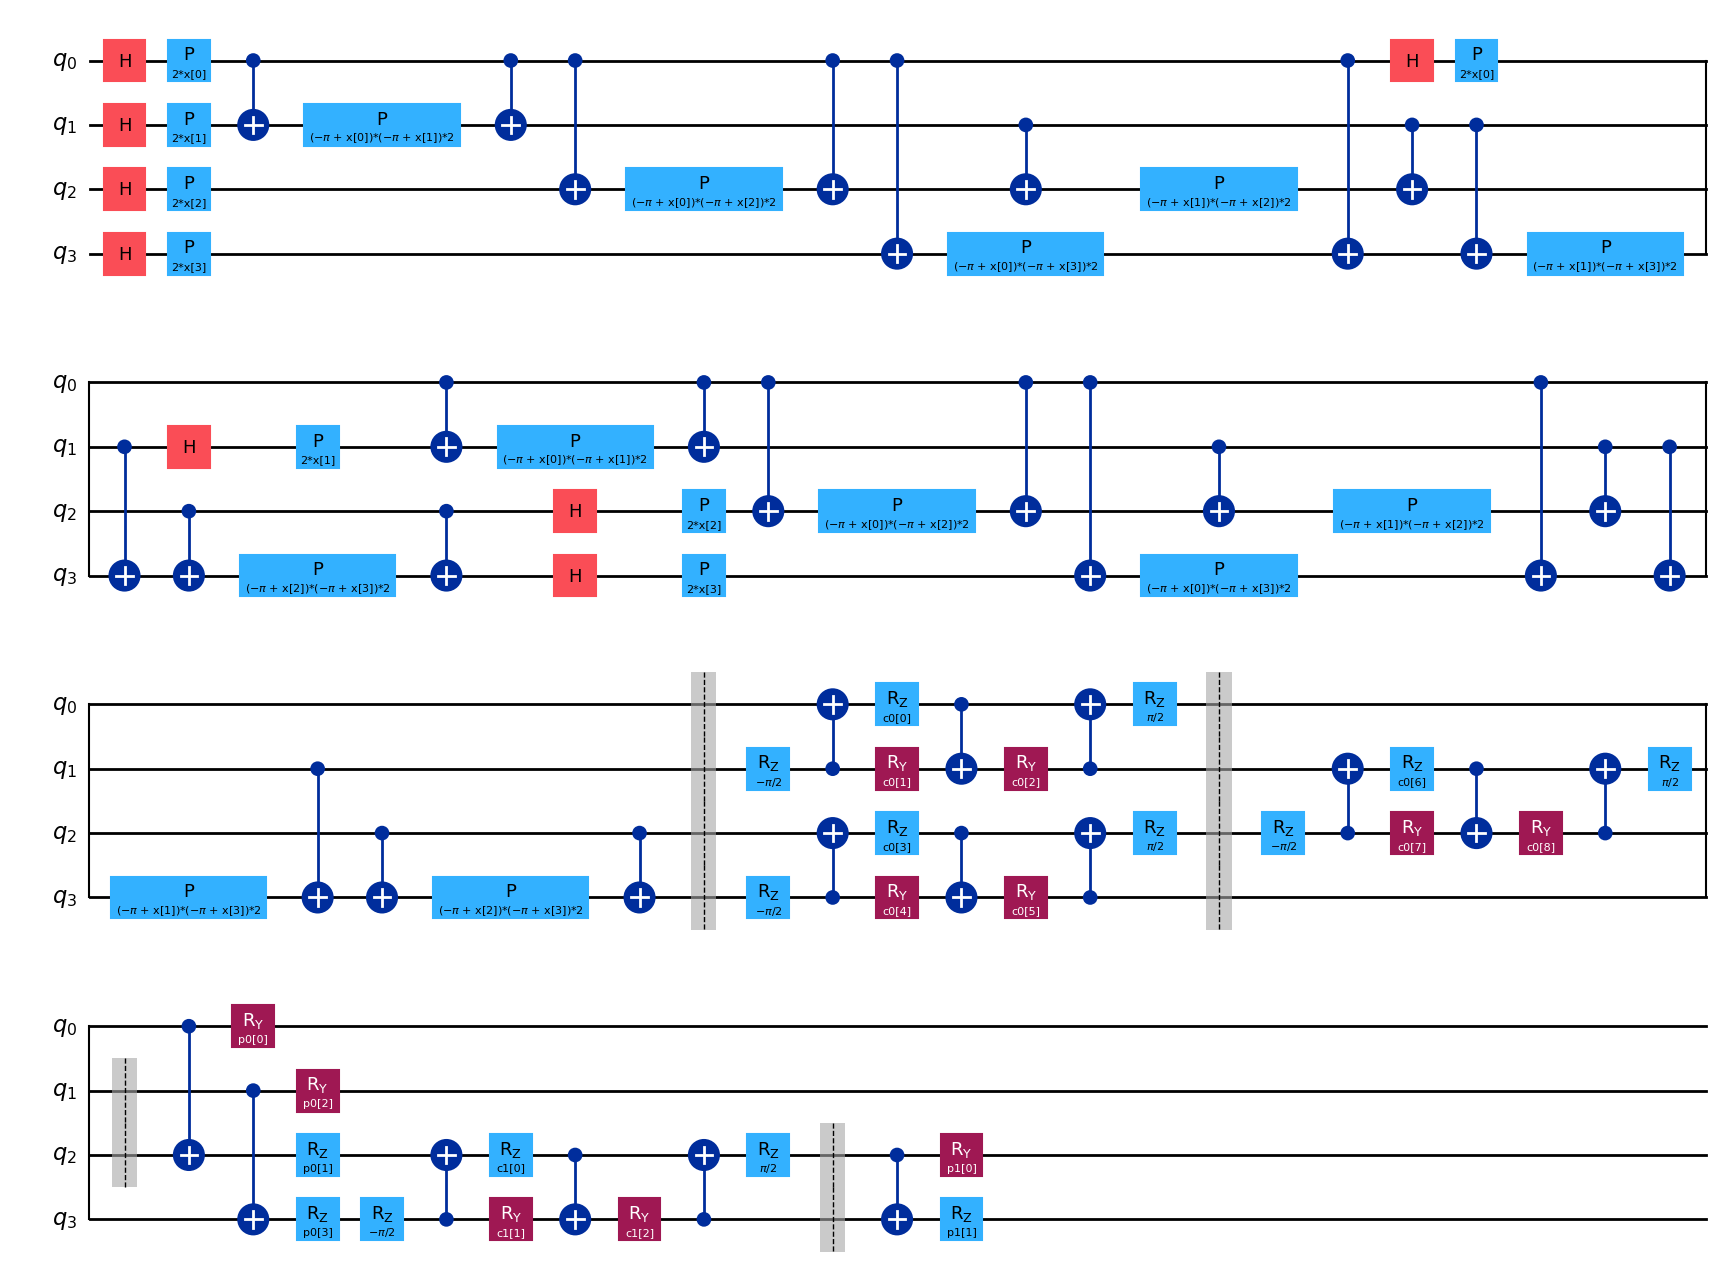

In [18]:
# construir QCNN

feature_map = zz_feature_map(num_qubits, reps=2)
qcnn_ansatz = build_qcnn(num_qubits)


# circuito completo
qc = QuantumCircuit(num_qubits)
qc.compose(feature_map, inplace=True)
qc.barrier()
qc.compose(qcnn_ansatz, inplace=True)
qc.draw('mpl')



------------------------------------------------------------
Time training: 2.5294947902361553 mins
Accuracy: 1.0
------------------------------------------------------------


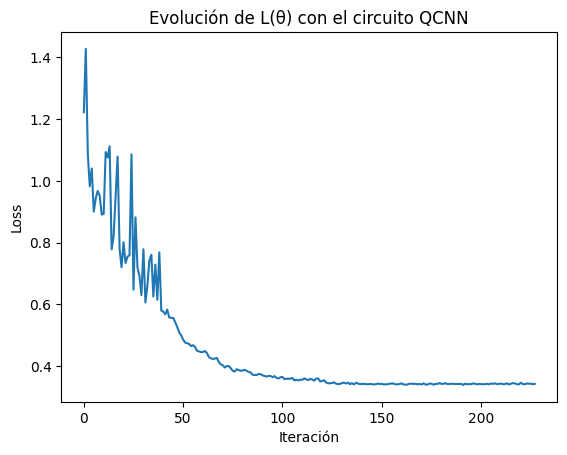

In [19]:
observable = SparsePauliOp.from_list([
    ("ZZII", 1),
    ("IIZZ", 1)
])
estimator = Estimator()

qnn = EstimatorQNN(
    circuit=qc,
    observables=observable,
    input_params=feature_map.parameters,
    weight_params=qcnn_ansatz.parameters,
    estimator=estimator
)

loss_history = []
classifier = NeuralNetworkClassifier(
    neural_network=qnn,
    optimizer=COBYLA(maxiter=500),
    callback = callback
)

start = time.time()
classifier.fit(X_train, y_train)
end = time.time()


y_pred2 = classifier.predict(X_test)
accuracy2 = accuracy_score(y_test, y_pred2)

print('-'*60)
print(f'Time training: {(end-start)/60} mins')
print("Accuracy:", accuracy2)
print('-'*60)

plt.plot(loss_history)
plt.xlabel("Iteración")
plt.ylabel("Loss")
plt.title("Evolución de L(θ) con el circuito QCNN")
plt.show()

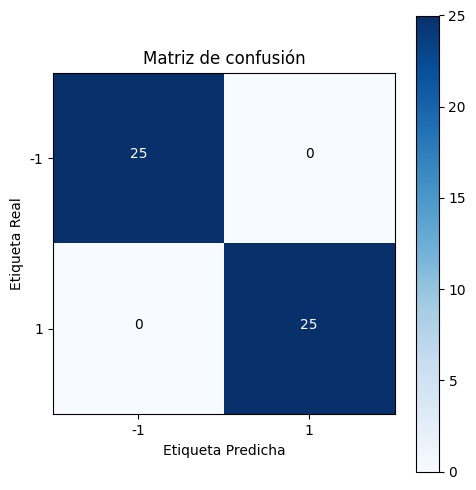

In [20]:
confusion = confusion_matrix(y_test, y_pred2)
plt.figure(figsize=(5, 5))
plt.imshow(confusion, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matriz de confusión')
plt.colorbar()


for i in range(confusion.shape[0]):
    for j in range(confusion.shape[1]):
        plt.text(j, i, format(confusion[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if confusion[i, j] > confusion.max() / 2 else "black")

plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.xticks([0, 1], ['-1', '1'])
plt.yticks([0, 1], ['-1', '1'])
plt.tight_layout()
plt.show()